[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO26 Object Detection on a Custom Dataset

---

[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolo26-custom-data/) [![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO26 introduces a unified architecture designed to support detection, segmentation, and pose tasks within a single model family. The model uses an anchor-free design with a decoupled head.

## Setup

### Configure API keys

To fine-tune YOLO26, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Apr 21 14:46:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies required for YOLO26

In [3]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [4]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [5]:
!yolo task=detect mode=predict model=yolo26m.pt source={HOME}/dog-2.jpeg save=True verbose=False

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,411,132 parameters, 0 gradients, 68.2 GFLOPs
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

In [6]:
!ls -la {HOME}/runs/detect/predict/

total 420
drwxr-xr-x 2 root root   4096 Apr 21 14:47 .
drwxr-xr-x 3 root root   4096 Apr 21 14:47 ..
-rw-r--r-- 1 root root 420529 Apr 21 14:47 dog-2.jpg


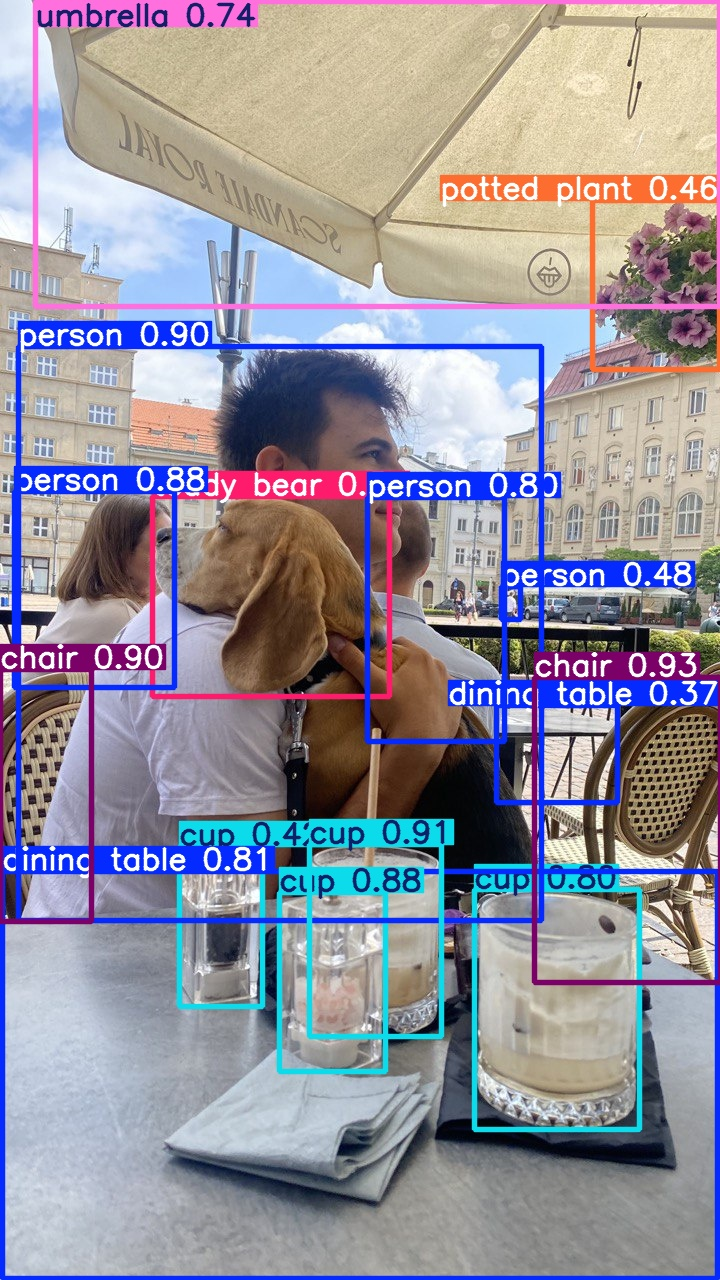

In [7]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog-2.jpg', width=600)

### SDK

In [8]:
from ultralytics import YOLO
from PIL import Image

model = YOLO('yolo26m.pt')
image = Image.open(f'{HOME}/dog-2.jpeg')
result = model.predict(image, verbose=False)[0]

**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [9]:
result.boxes.xyxy

tensor([[5.3404e+02, 6.7770e+02, 7.2000e+02, 9.8270e+02],
        [3.0912e+02, 8.4417e+02, 4.4110e+02, 1.0363e+03],
        [5.4420e-01, 6.6944e+02, 9.1546e+01, 9.2108e+02],
        [1.8636e+01, 3.4667e+02, 5.4174e+02, 9.2046e+02],
        [2.7974e+02, 8.9215e+02, 3.8501e+02, 1.0716e+03],
        [1.4987e+01, 4.9126e+02, 1.7489e+02, 6.8704e+02],
        [2.8078e+00, 8.7185e+02, 7.1774e+02, 1.2785e+03],
        [3.6707e+02, 4.9763e+02, 5.0493e+02, 7.4178e+02],
        [4.7472e+02, 8.8993e+02, 6.4000e+02, 1.1297e+03],
        [3.5814e+01, 1.0317e+00, 7.1993e+02, 3.0651e+02],
        [5.0156e+02, 5.8670e+02, 5.2026e+02, 6.1997e+02],
        [5.9209e+02, 2.0039e+02, 7.1999e+02, 3.6992e+02],
        [1.7925e+02, 8.4660e+02, 2.6239e+02, 1.0062e+03],
        [4.9622e+02, 7.0596e+02, 6.1744e+02, 8.0277e+02],
        [1.5233e+02, 4.9656e+02, 3.8946e+02, 6.9643e+02]], device='cuda:0')

In [10]:
result.boxes.conf

tensor([0.9344, 0.9107, 0.8983, 0.8982, 0.8838, 0.8816, 0.8050, 0.8048, 0.8017, 0.7403, 0.4840, 0.4638, 0.4220, 0.3653, 0.3069], device='cuda:0')

In [11]:
result.boxes.cls

tensor([56., 41., 56.,  0., 41.,  0., 60.,  0., 41., 25.,  0., 58., 41., 60., 77.], device='cuda:0')

**NOTE:** YOLO26 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [12]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

In [13]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        smart_position=True
    )

    out = image.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

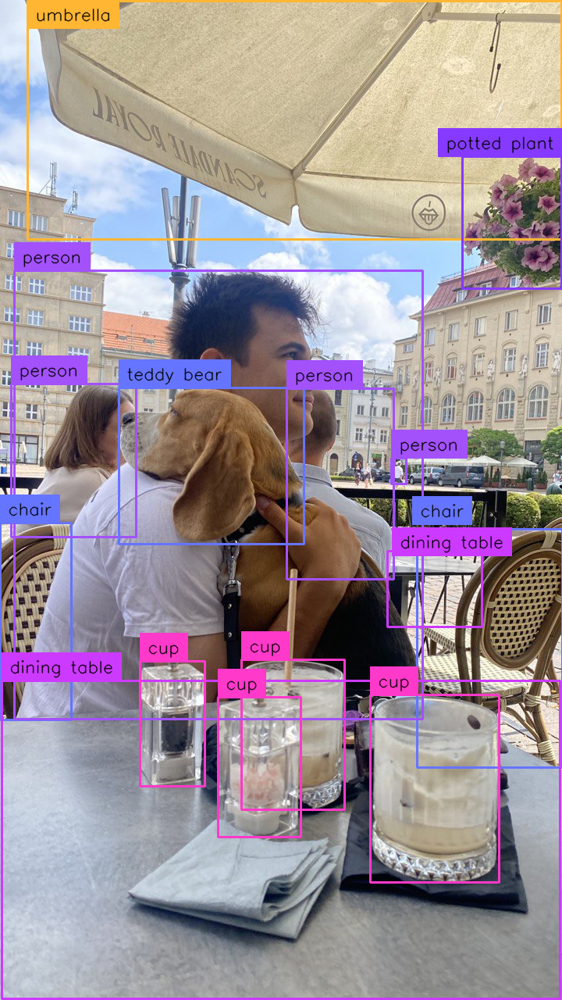

In [14]:
annotated_image = annotate(image, detections)
annotated_image

## Fine-tune YOLO26 on custom dataset

**NOTE:** When training YOLO26, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [15]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

# ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
# rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# workspace = rf.workspace("roboflow-jvuqo")
# project = workspace.project("basketball-player-detection-3-ycjdo")
# version = project.version(14)
# dataset = version.download("yolo26")

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="FxLEUL1eiJB51PvvOram")
project = rf.workspace("tungwork").project("ppe-mask-glove-mergev2-kjeqd")
version = project.version(1)
dataset = version.download("yolo26")


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-mask-glove-mergev2-1 in yolo26:: 100%|██████████| 7741/7741 [00:00<00:00, 8926.15it/s]


## Custom Training

In [19]:
%cd {HOME}

!yolo task=detect mode=train model=yolo26n.pt data={dataset.location}/data.yaml epochs=30 imgsz=320 plots=True batch=0.8

/content
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=0.8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/ppe-mask-glove-mergev2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [20]:
!ls {HOME}/runs/detect/train/

args.yaml  labels.jpg  train_batch0.jpg  weights


In [21]:
 from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train/confusion_matrix.png'

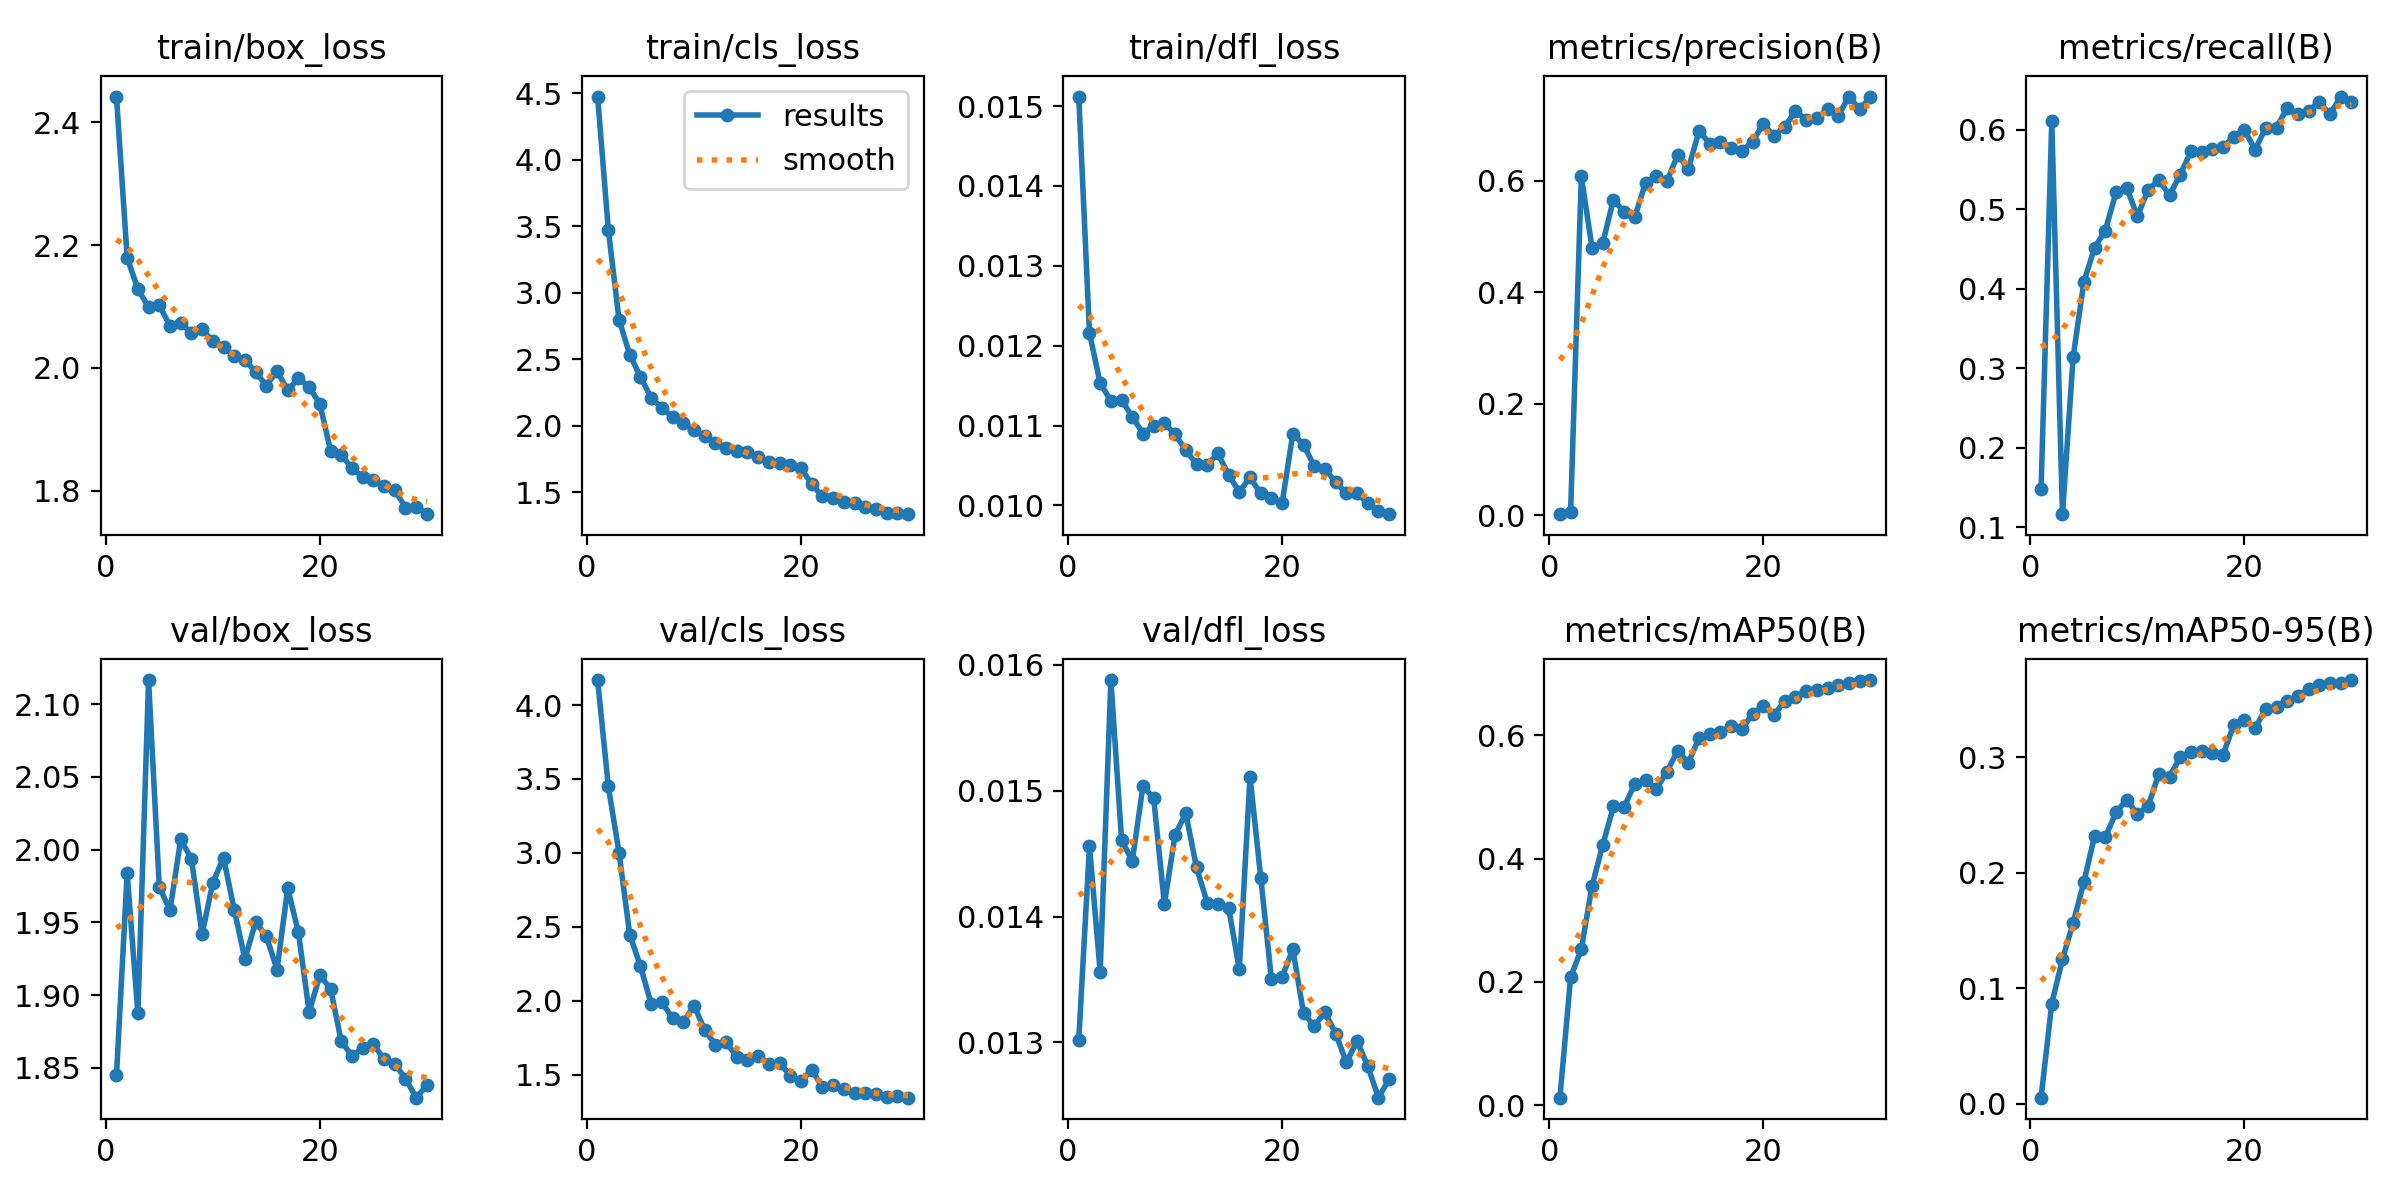

In [24]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train-2/results.png', width=600)

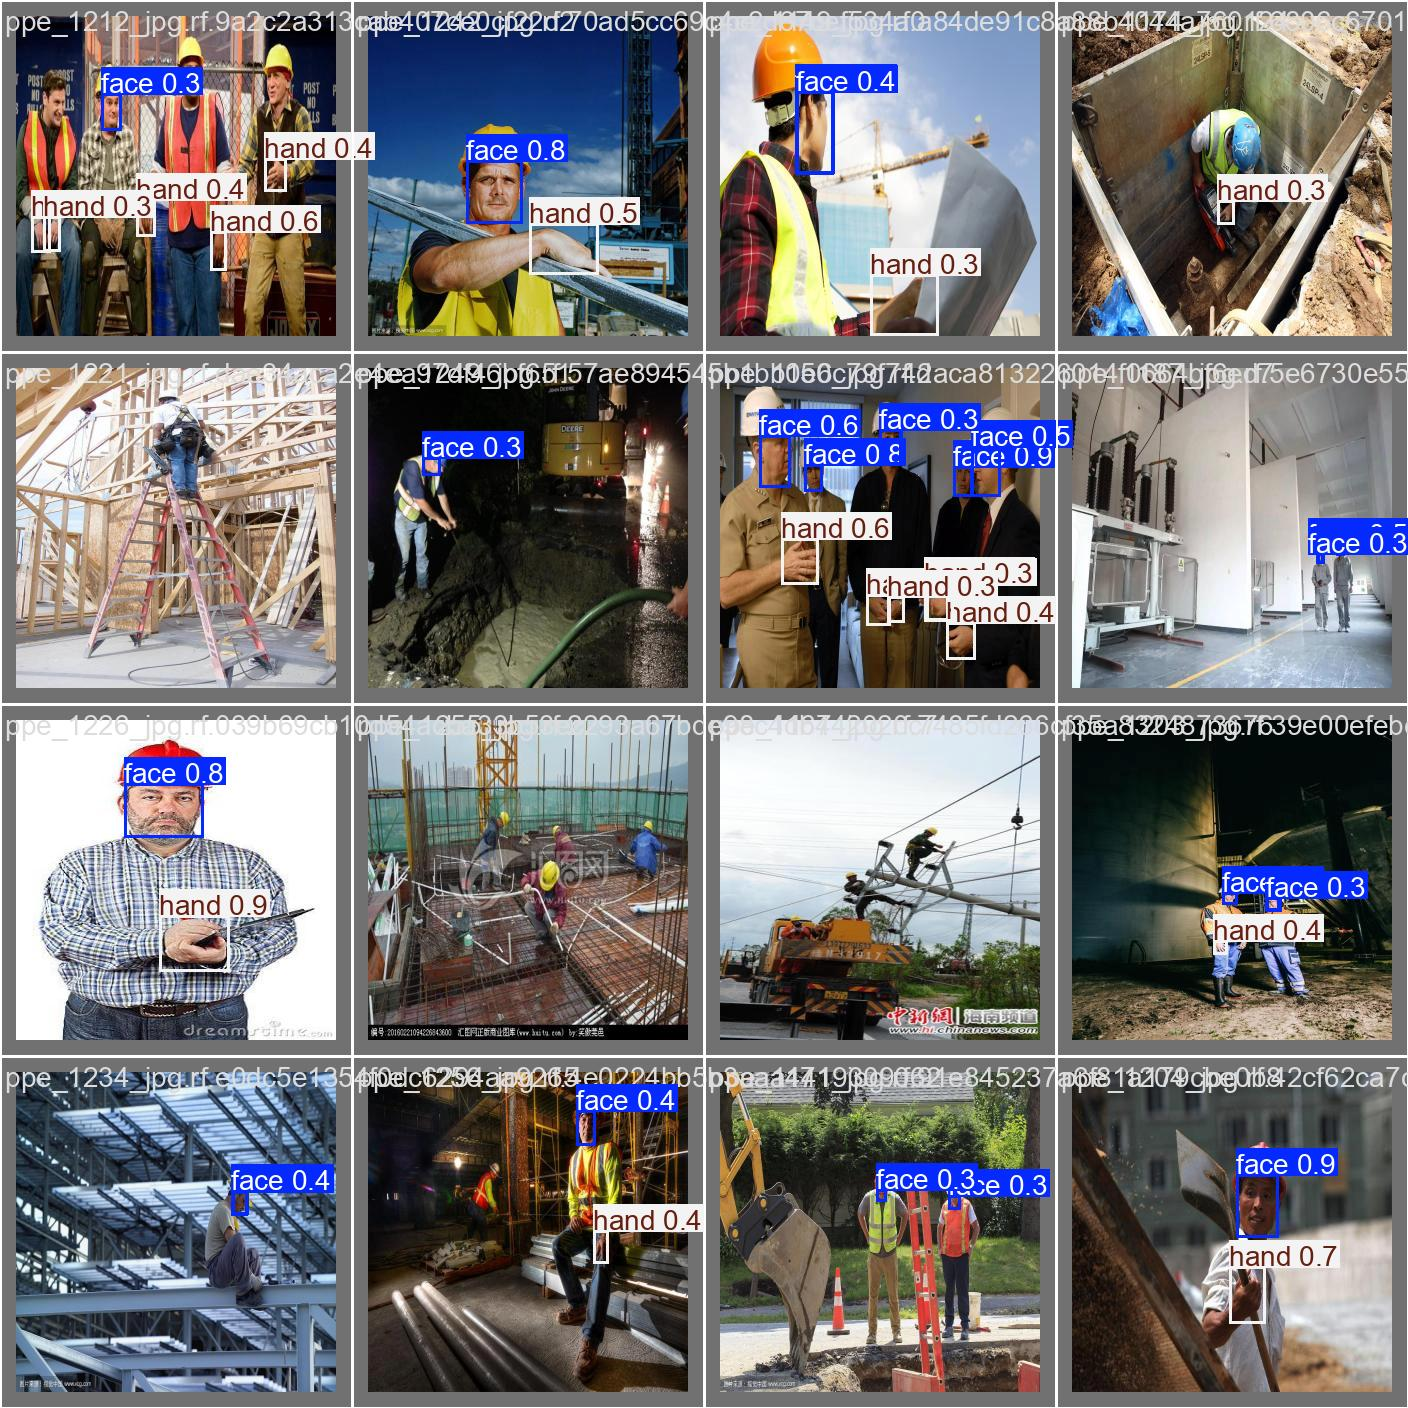

In [25]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train-2/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [27]:
!yolo task=detect mode=val model={HOME}/runs/detect/train-2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 659.2±244.8 MB/s, size: 13.7 KB)
val: Scanning /content/datasets/ppe-mask-glove-mergev2-1/valid/labels.cache... 455 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 79.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 7.7it/s 3.8s
                   all        455       1537       0.75      0.635      0.689      0.366
                  face        221        386      0.764      0.856      0.872      0.419
                 glove        214        532      0.693      0.402      0.487      0.261
                  hand        197        473      0.744      0.468      0.549      0.244
                  mask         94        146      0.797      0.815      0.849      0.541
Speed: 0.4ms preproc

## Inference with custom model

### CLI

In [28]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train-2/weights/best.pt source={dataset.location}/test/images save=True verbose=False

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
Results saved to /content/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


### SDK

In [29]:
from ultralytics import YOLO

model = YOLO(f'{HOME}/runs/detect/train-2/weights/best.pt')

In [ ]:
import supervision as sv

ds_test = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

In [ ]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    color = sv.ColorPalette.from_hex([
        "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00",
        "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    ])

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    box_annotator = sv.BoxAnnotator(color=color)
    label_annotator = sv.LabelAnnotator(
        color=color,
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        smart_position=True
    )

    out = image.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

In [ ]:
import random
import matplotlib.pyplot as plt

N = 9
L = len(ds_test)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)
    result = model.predict(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    annotated_image = annotate(image, detections)
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

In [ ]:
annotated_images[0]

## Deploy model on Roboflow

Upload the YOLO26 weights to Roboflow Deploy for inference on Roboflow infrastructure built for scale.

In [ ]:
project.version(dataset.version).deploy(model_type="yolo26", model_path=f"{HOME}/runs/detect/train/")

## Run inference with a Roboflow hosted model

Load a trained model from Roboflow and run inference.

In [ ]:
!pip install -q inference

In [ ]:
from inference import get_model
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

model_id = project.id.split("/")[1] + "/" + dataset.version
model = get_model(model_id, ROBOFLOW_API_KEY)

In [ ]:
import random
import matplotlib.pyplot as plt

N = 9
L = len(ds_test)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)
    result = model.infer(image)[0]
    detections = sv.Detections.from_inference(result)
    annotated_image = annotate(image, detections)
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

In [ ]:
annotated_images[0]

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>